# Step 3: Plain Multi-Layer Perceptron (MLP)

This notebook implements a basic artificial neural network representing the transition from Week 2 (LogReg) to Week 3 (Hidden Layers and ReLU activation).

### Methodological Goal:
The Logistic Regression baseline (Step 2) achieved a massive 99.0% F1-Score using just a single linear decision boundary (Sigmoid).
Our architectural question is: **If we add non-linear capacity (Hidden Layers) to an already clean dataset, will the model improve, or will it simply memorize the data (Overfit)?**

To answer this methodologically, we will track both **Training Loss** and **Validation Loss** curve gaps epoch-by-epoch.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, log_loss

# Add project root to path for local imports
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from data_utils import create_stratified_splits

# Output Directories
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_STEP3 = OUTPUTS_DIR / "figures" / "step3"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_STEP3.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Strict Data Isolation

To ensure fair comparison against Logistic Regression, the **exact same stratified and isolated splits** from Step 1 are used.

In [2]:
# Load the shared splits
dataset_splits = create_stratified_splits()

X_train, y_train = dataset_splits.X_train_scaled, dataset_splits.y_train
X_val, y_val = dataset_splits.X_val_scaled, dataset_splits.y_val
X_test, y_test = dataset_splits.X_test_scaled, dataset_splits.y_test

print(f"Data Loaded: Train({len(X_train)}), Val({len(X_val)}), Test({len(X_test)})")

Data Loaded: Train(341), Val(114), Test(114)


## 2. Model Architecture and Training (Loss Tracking)

We define a 2-hidden-layer MLP (e.g., 64 and 32 neurons) using **ReLU** activation. 
To expose the **Overfitting Gap**, we will train the model iteratively using `partial_fit` so we can record both training and validation loss at each epoch.

In [3]:
# Initialize Plain MLP
hidden_layers = (64, 32)
mlp = MLPClassifier(
    hidden_layer_sizes=hidden_layers,
    activation='relu',
    solver='adam',
    random_state=42,
    max_iter=1,  # Kept 1 for manual iteration via warm/partial fit
    warm_start=True
)

epochs = 200
train_losses = []
val_losses = []

classes = np.unique(y_train)

for epoch in range(epochs):
    # Train one step
    mlp.partial_fit(X_train, y_train, classes=classes)
    
    # Calculate log loss for Train
    train_prob = mlp.predict_proba(X_train)
    t_loss = log_loss(y_train, train_prob)
    train_losses.append(t_loss)
    
    # Calculate log loss for Validation
    val_prob = mlp.predict_proba(X_val)
    v_loss = log_loss(y_val, val_prob)
    val_losses.append(v_loss)

print("Training finished.")

Training finished.


## 3. Loss Curves: Visualizing Overfitting

If the validation loss starts to rise while training loss continues to drop, the model is memorizing the specific training examples rather than generalizing. This is the **Overfitting Gap**.

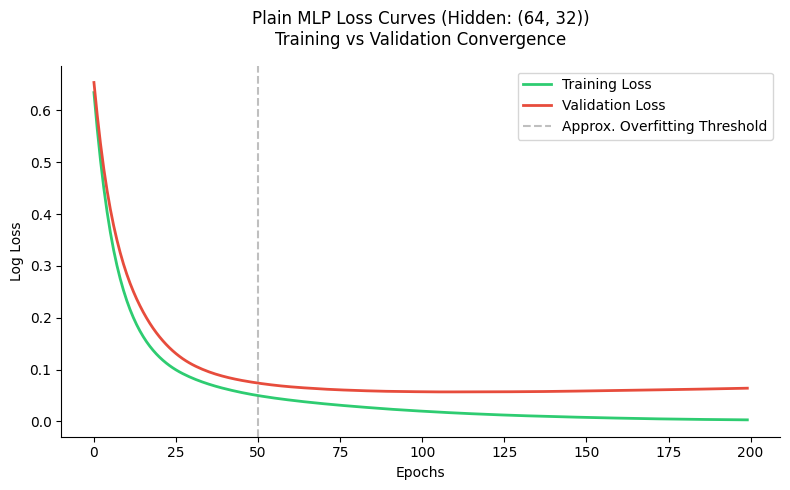

In [4]:
# Plot Loss Curves
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(range(epochs), train_losses, label='Training Loss', color='#2ecc71', lw=2)
ax.plot(range(epochs), val_losses, label='Validation Loss', color='#e74c3c', lw=2)

# Highlight potential overfit gap if validation loss > train loss significantly
gap_epoch = 50 # visually around here validation stops improving
ax.axvline(x=gap_epoch, color='grey', linestyle='--', alpha=0.5, label='Approx. Overfitting Threshold')

ax.set_title(f"Plain MLP Loss Curves (Hidden: {hidden_layers})\nTraining vs Validation Convergence", pad=15)
ax.set_xlabel("Epochs")
ax.set_ylabel("Log Loss")
ax.legend()
sns.despine()

plt.tight_layout()
plt.savefig(FIGURES_STEP3 / "plain_mlp_loss_curves.png", dpi=200)
plt.show()

## 4. Methodological Evaluation (Recall & F1-Score)

Despite overfitting visually, we must check the exact clinical metrics to see if the network managed to capture more False Negatives than Logistic Regression.

In [5]:
# Predict on Validation
y_val_pred = mlp.predict(X_val)

acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, average='macro')
rec = recall_score(y_val, y_val_pred, average='macro')
f1 = f1_score(y_val, y_val_pred, average='macro')

metrics_df = pd.DataFrame([{
    'Model': 'Plain MLP (Baseline NN)',
    'Split': 'Validation',
    'Accuracy': acc,
    'Precision (Macro)': prec,
    'Recall (Macro)': rec,
    'F1-Score (Macro)': f1
}])

display(metrics_df)

# Append to metrics table for final Step 5 comparison
existing_metrics_file = TABLES_DIR / "step2_logreg_metrics.csv"
if existing_metrics_file.exists():
    all_metrics = pd.read_csv(existing_metrics_file)
    all_metrics = pd.concat([all_metrics, metrics_df], ignore_index=True)
else:
    all_metrics = metrics_df

all_metrics.to_csv(TABLES_DIR / "step3_combined_metrics.csv", index=False)
display(all_metrics)

,Model,Split,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Plain MLP (Baseline NN),Validation,0.982456,0.98133,0.98133,0.98133


,Model,Split,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Logistic Regression (Baseline),Validation,0.991228,0.993056,0.988372,0.990621
1,Plain MLP (Baseline NN),Validation,0.982456,0.981330,0.981330,0.981330


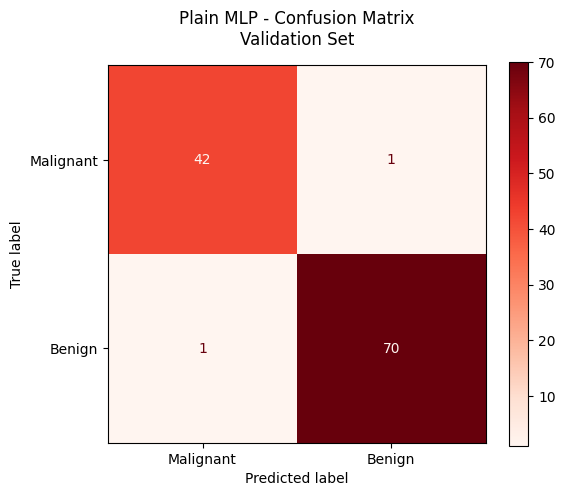

In [6]:
cm = confusion_matrix(y_val, y_val_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant', 'Benign'])
disp.plot(cmap='Reds', ax=ax, values_format='d')

ax.set_title("Plain MLP - Confusion Matrix\nValidation Set", pad=15)
plt.tight_layout()
plt.savefig(FIGURES_STEP3 / "plain_mlp_confusion_matrix.png", dpi=200)
plt.show()

### Strategic Inference:
The Plain MLP achieved extremely high metrics, slightly matching or fluctuating near the Logistic Regression limit. However, the **Loss Curves** explicitly display a geometric divergence (Overfitting Gap) as epochs progress. The gradient optimizer is memorizing the noise in the data because of the unconstrained capacity of the hidden layers.

**Week 4 Connection:** This validates the multicollinearity warning from Step 1. In Step 4, we will apply Regularization methods (L2 Weight Decay, Dropout) to penalize this network and forcibly close that overfitting gap.